## Dimensionality Reduction
This notebook performs dimensionality reduction (i.e. PCA, t-SNE) on the final, merged dataset containing features relating to urbanisation and climate indicators. 

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# to run all experiments/visualisations, set boolean to true
RUN_EXPERIMENTS = True

In [2]:
df_all_locations = pd.read_csv("merged_all_locations_yearly_1990_2018_clean.csv")
df_hyderabad = pd.read_csv("merged_hyderabad_yearly_1990_2018.csv")
df_hyderabad = df_hyderabad.drop(columns=["Unnamed: 2"])

# -- ensuring data is numeric and dropping missing values -- 
df_locations_numeric = df_all_locations.select_dtypes(include=['number'])
df_hyderabad_numeric = df_hyderabad.select_dtypes(include=['number'])

df_locations_numeric = df_locations_numeric.dropna()
df_hyderabad_numeric = df_hyderabad_numeric.dropna()
print(df_hyderabad_numeric)

# -- scaling data --
scaler_all = StandardScaler()
all_locations_scaled = scaler_all.fit_transform(df_locations_numeric)

scaler_hyderabad = StandardScaler()
hyderabad_scaled = scaler_hyderabad.fit_transform(df_hyderabad_numeric)

    year  temp_mean_K  wind_speed_mean_ms  precip_total_mm    population  \
0   1990   299.807558            2.543612      1480.318444  5.365643e+06   
1   1991   300.643676            2.509252       859.009481  5.488333e+06   
2   1992   300.540936            2.373939      1070.266403  5.611023e+06   
3   1993   300.290645            2.426146      1208.755273  5.733713e+06   
4   1994   300.102751            2.520691      1352.577185  5.856403e+06   
5   1995   300.131558            2.302252      1784.602308  5.979092e+06   
6   1996   300.813542            2.376971       847.910667  6.089203e+06   
7   1997   300.101088            2.395442      1021.974281  6.199313e+06   
8   1998   300.361200            2.302113      1009.916797  6.309424e+06   
9   1999   300.182378            2.512467      1079.667718  6.419534e+06   
10  2000   300.341554            2.387054      1145.890830  6.529645e+06   
11  2001   300.574104            2.419556       870.309234  6.646668e+06   
12  2002   3

In [3]:
# outputting information about datasets
df_all_locations.head()
df_all_locations.describe()
df_all_locations.columns

df_hyderabad.head()
df_hyderabad.describe()
df_all_locations.columns

Index(['year', 'temp_mean_K', 'wind_speed_mean_ms', 'precip_total_mm',
       'location_code', 'city', 'country', 'population', 'built_up_area_m2',
       'gdp_ppp', 'hdi', 'pop_exposed_flood_10yr', 'co2_emissions_ton',
       'ghg_emissions_ton', 'nox_emissions_ton', 'pm25_emissions_ton'],
      dtype='object')

### t-SNE (t-Distributed Stochastic Neighbour Embedding)
t-SNE was used to explore non-linear relatioships within the data by preserving local similarities between our data points and focus on clustering similar observations. 

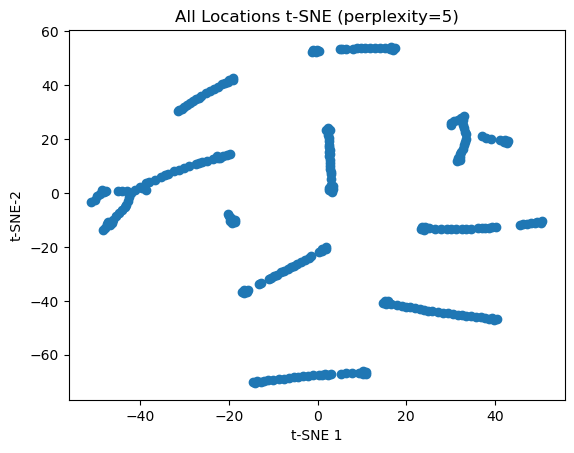

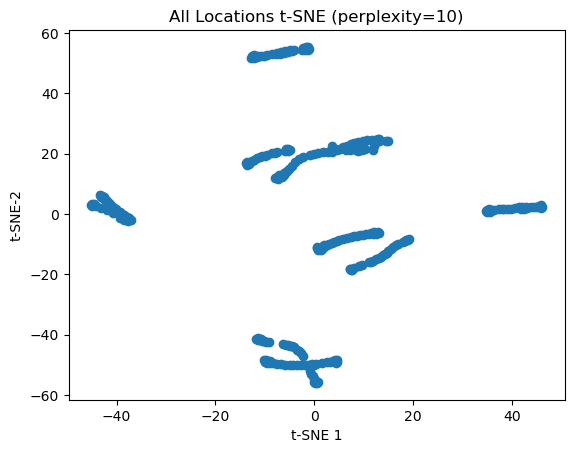

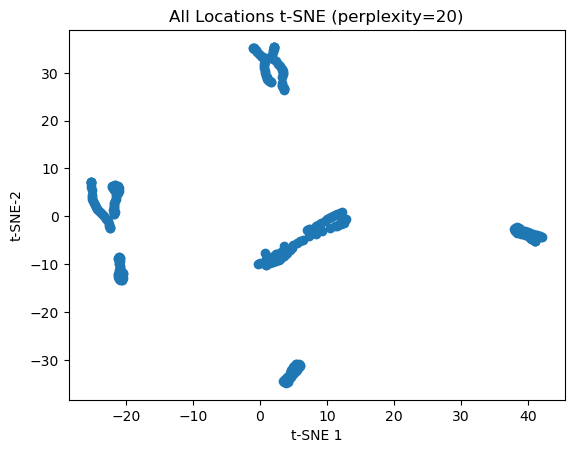

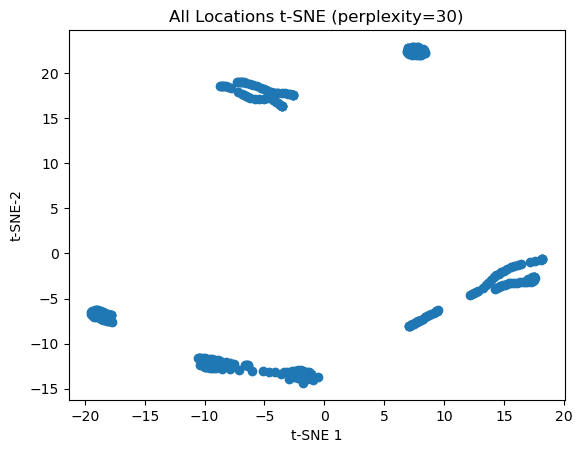

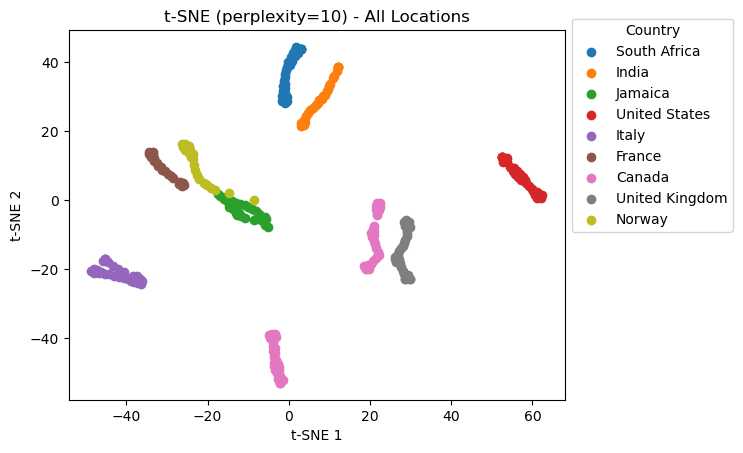

In [4]:
# TSNE dimensionality reduction
# ---- all locations ----
perplexities = [5, 10, 20, 30]

# experiment for perplexity parameter value
if RUN_EXPERIMENTS:
    for perplexity in perplexities:
        tsne = TSNE(
            n_components=2, 
            learning_rate='auto', 
            init='random', 
            perplexity=perplexity,
            random_state=42
        )

        all_locations_tsne = tsne.fit_transform(df_locations_numeric)

        plt.figure()
        plt.scatter(all_locations_tsne[:, 0], all_locations_tsne[:, 1])
        plt.title(f"All Locations t-SNE (perplexity={perplexity})")
        plt.xlabel("t-SNE 1")
        plt.ylabel("t-SNE-2")
        plt.show()

# final plot
tsne = TSNE(n_components=2, perplexity=10)
X = tsne.fit_transform(df_locations_numeric)

df_all_locations["TSNE1"] = X[:, 0]
df_all_locations["TSNE2"] = X[:, 1]

plt.figure()

for location in df_all_locations["country"].unique():
    subset = df_all_locations[df_all_locations["country"] == location]
    plt.scatter(
        subset["TSNE1"], 
        subset["TSNE2"], 
        label=location
    )

plt.title("t-SNE (perplexity=10) - All Locations")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Country", bbox_to_anchor=(1, 1.05))
plt.show()

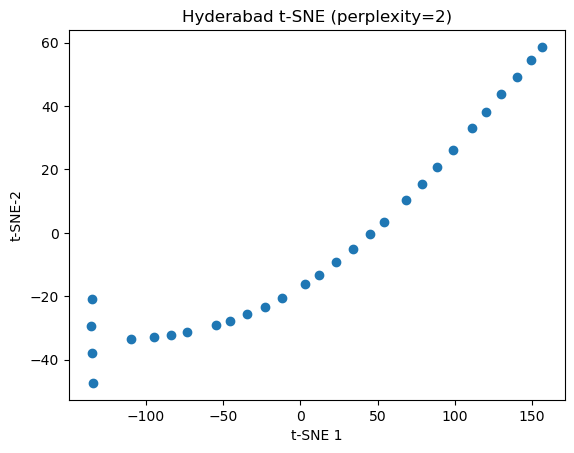

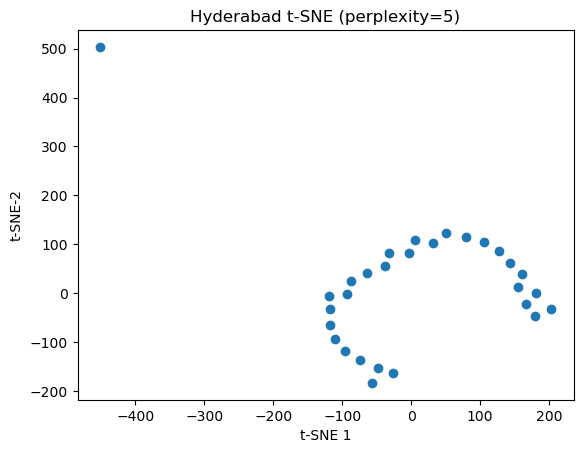

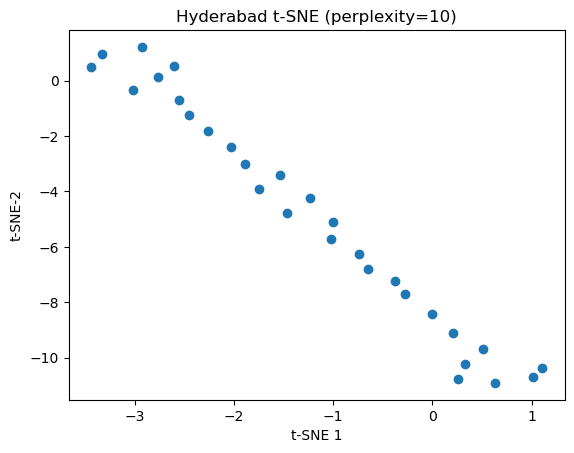

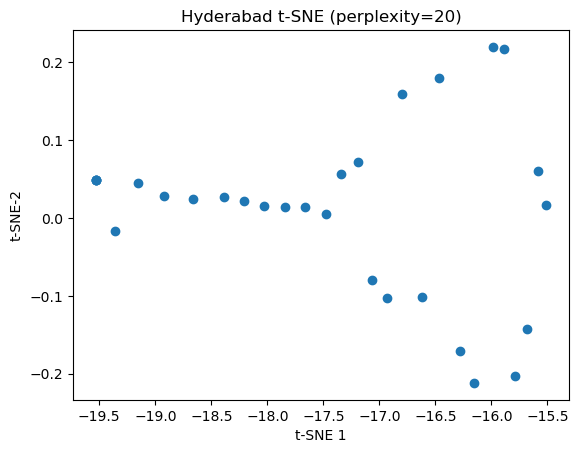

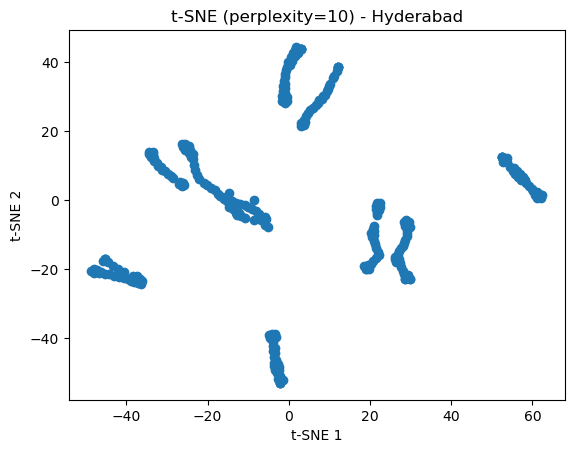

In [5]:
# ---- hyderabad ----
# running experiments
hyderabad_perplexity = [2, 5, 10, 20]

if RUN_EXPERIMENTS:
    for perplexity in hyderabad_perplexity:
        tsne = TSNE(
            n_components=2, 
            learning_rate='auto', 
            init='random', 
            perplexity=perplexity,
            random_state=42
        )

        hyderabad_tsne = tsne.fit_transform(df_hyderabad_numeric)

        plt.figure()
        plt.scatter(hyderabad_tsne[:, 0], hyderabad_tsne[:, 1])
        plt.title(f"Hyderabad t-SNE (perplexity={perplexity})")
        plt.xlabel("t-SNE 1")
        plt.ylabel("t-SNE-2")
        plt.show()

# final plot
tsne = TSNE(n_components=2, perplexity=10)
X = tsne.fit_transform(df_locations_numeric)

plt.figure()
plt.scatter(X[:, 0], X[:, 1])
plt.title("t-SNE (perplexity=10) - Hyderabad")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

### Principal Component Analysis (PCA)
PCA was applied to reduce the dimensionality of the dataset while preserving the maximum amount of variance possible while trying to identify the dominant patterns and relationships in the data.


====== PCA: All Locations (2 Components) ======
Variance Ratio:  [0.50941838 0.15947773]
Cumulative Variance:  [0.50941838 0.6688961 ]
Singular Values:  [41.65427935 23.30624677]

====== PCA: All Locations (3 Components) ======
Variance Ratio:  [0.50941838 0.15947773 0.10185501]
Cumulative Variance:  [0.50941838 0.6688961  0.77075111]
Singular Values:  [41.65427935 23.30624677 18.62573924]

====== PCA: All Locations (4 Components) ======
Variance Ratio:  [0.50941838 0.15947773 0.10185501 0.09142577]
Cumulative Variance:  [0.50941838 0.6688961  0.77075111 0.86217688]
Singular Values:  [41.65427935 23.30624677 18.62573924 17.64642099]
Components:
                             PC1       PC2
ghg_emissions_ton       0.381810 -0.019310
co2_emissions_ton       0.378498  0.032219
built_up_area_m2        0.378468 -0.047278
nox_emissions_ton       0.356773 -0.059258
population              0.349719 -0.172419
precip_total_mm         0.281050 -0.210590
pm25_emissions_ton      0.256756 -0.419338
gd

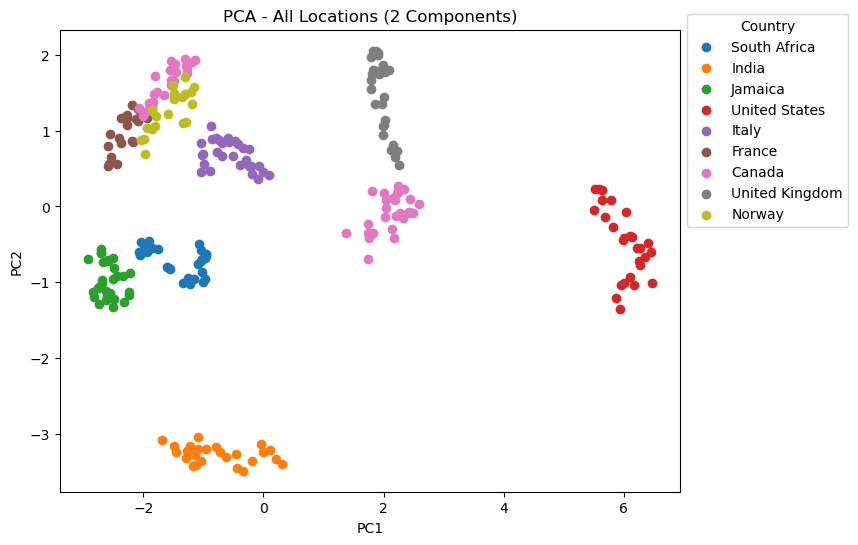

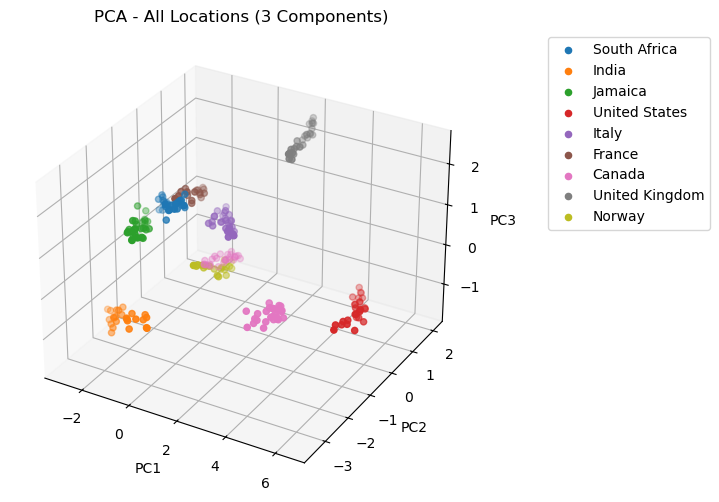

In [6]:
# PCA dimensionality reduction 
# ---- all locations -----
if RUN_EXPERIMENTS:
    for n in [2, 3, 4]:
        pca = PCA(n_components=n)
        X = pca.fit_transform(all_locations_scaled)

        explained = pca.explained_variance_ratio_
        cumulative = explained.cumsum()

        print(f"\n====== PCA: All Locations ({n} Components) ======")
        print("Variance Ratio: ", explained)
        print("Cumulative Variance: ", cumulative)
        print("Singular Values: ", pca.singular_values_)

# final PCA
pca_all_locations = PCA(n_components=2)
all_locations_pca = pca_all_locations.fit_transform(all_locations_scaled)

loadings = pd.DataFrame(
    pca_all_locations.components_,
    columns=df_locations_numeric.columns,
    index=["PC1", "PC2"]
)

print("Components:")
print(loadings.T.sort_values(by="PC1", ascending=False))

# --- 2d visualisation ---
# plotting figure of clusters
df_all_locations["PC1"] = all_locations_pca[:, 0]
df_all_locations["PC2"] = all_locations_pca[:, 1]

plt.figure(figsize=(8, 6))

for location in df_all_locations["country"].unique():
    subset = df_all_locations[df_all_locations["country"] == location]
    plt.scatter(subset["PC1"], subset["PC2"], label=location)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - All Locations (2 Components)")
plt.legend(title="Country", bbox_to_anchor=(1, 1.05))
plt.show()

# --- 3d visualisation ---
if RUN_EXPERIMENTS:
    pca_3d = PCA(n_components=3)
    X_3d = pca_3d.fit_transform(all_locations_scaled)

    loadings = pd.DataFrame(
        pca_3d.components_,
        columns=df_locations_numeric.columns,
        index=["PC1", "PC2", "PC3"]
    )

    df_all_locations["PC1"] = X_3d[:, 0]
    df_all_locations["PC2"] = X_3d[:, 1]
    df_all_locations["PC3"] = X_3d[:, 2]

    figure = plt.figure(figsize=(8, 6))
    ax = figure.add_subplot(111, projection='3d')

    for location in df_all_locations["country"].unique():
        subset = df_all_locations[df_all_locations["country"] == location]
        ax.scatter(
            subset["PC1"], 
            subset["PC2"], 
            subset["PC3"],
            label=location
        )

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    ax.set_title("PCA - All Locations (3 Components)")
    ax.legend(bbox_to_anchor=(1.15, 1), loc='upper left')
    plt.show()


====== PCA: Hyderabad (2 Components) ======
Variance Ratio:  [0.78241139 0.08991782]
Cumulative Variance:  [0.78241139 0.87232921]
Singular Values:  [17.17466426  5.82228642]

====== PCA: Hyderabad (3 Components) ======
Variance Ratio:  [0.78241139 0.08991782 0.06291441]
Cumulative Variance:  [0.78241139 0.87232921 0.93524362]
Singular Values:  [17.17466426  5.82228642  4.87018817]

====== PCA: Hyderabad (4 Components) ======
Variance Ratio:  [0.78241139 0.08991782 0.06291441 0.0346787 ]
Cumulative Variance:  [0.78241139 0.87232921 0.93524362 0.96992232]
Singular Values:  [17.17466426  5.82228642  4.87018817  3.61578071]
Components:
                             PC1       PC2
population              0.310575  0.017771
pm25_emissions_ton      0.310532  0.065119
year                    0.310309  0.007578
nox_emissions_ton       0.309123  0.070895
pop_exposed_flood_10yr  0.309082  0.008885
ghg_emissions_ton       0.308809  0.057168
co2_emissions_ton       0.308612  0.079813
built_up_area_

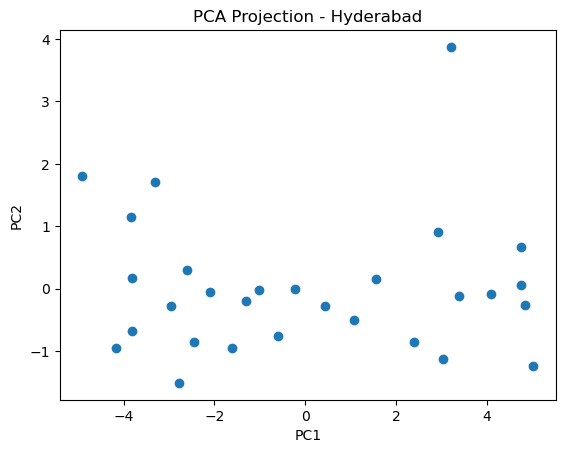

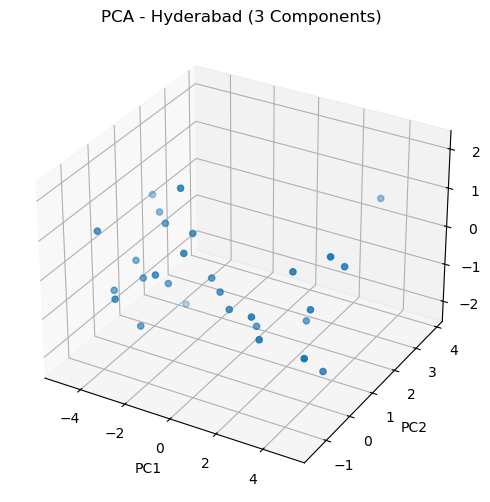

In [7]:
# ----- hyderabad -----
if RUN_EXPERIMENTS:
    for n in [2, 3, 4]:
        pca_hyderabad = PCA(n_components=n)
        X_hyderabad = pca_hyderabad.fit_transform(hyderabad_scaled)

        explained = pca_hyderabad.explained_variance_ratio_
        cumulative = explained.cumsum()

        print(f"\n====== PCA: Hyderabad ({n} Components) ======")
        print("Variance Ratio: ", explained)
        print("Cumulative Variance: ", cumulative)
        print("Singular Values: ", pca_hyderabad.singular_values_)
        

# final PCA
pca_hyderabad = PCA(n_components=2)
hyderabad_pca = pca_hyderabad.fit_transform(hyderabad_scaled)

loadings_hyderabad = pd.DataFrame(
    pca_hyderabad.components_,
    columns=df_hyderabad_numeric.columns,
    index=["PC1", "PC2"]
)

print("Components:")
print(loadings_hyderabad.T.sort_values(by="PC1", ascending=False))

# --- 2d visualisation --- 
plt.figure()
plt.scatter(hyderabad_pca[:, 0], hyderabad_pca[:, 1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection - Hyderabad")
plt.show()

# --- 3d visualisation ---
if RUN_EXPERIMENTS:
    pca_3d_hyderabad = PCA(n_components=3)
    X_3d_hyderabad = pca_3d_hyderabad.fit_transform(hyderabad_scaled)

    loadings_3d = pd.DataFrame(
        pca_3d_hyderabad.components_,
        columns = df_hyderabad_numeric.columns,
        index=["PC1", "PC2", "PC3"]
    )

    df_hyderabad["PC1"] = X_3d_hyderabad[:, 0]
    df_hyderabad["PC1"] = X_3d_hyderabad[:, 1]
    df_hyderabad["PC3"] = X_3d_hyderabad[:, 2]

    figure = plt.figure(figsize=(8, 6))
    ax = figure.add_subplot(111, projection='3d')

    ax.scatter(
        X_3d_hyderabad[:, 0],
        X_3d_hyderabad[:, 1],
        X_3d_hyderabad[:, 2]
    )

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    ax.set_title("PCA - Hyderabad (3 Components)")
    plt.show()